In [1]:
import math
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import tqdm
from networks import InvariantValueNet, ValueNet
random_key = jax.random.PRNGKey(0)


In [3]:
batch_size = 32
width = 32
sym_inv_reg_pairs = [(0.1,0.0), (0.05, 0.0), (0.2, 0.0), (0.0, 0.1),(0.1, 0.1)]
value_net_equiv = InvariantValueNet(
    key=jax.random.PRNGKey(0),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
)


value_net_nosym = ValueNet(
    key=jax.random.PRNGKey(0),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
)

value_net_sym = ValueNet(
    key=jax.random.PRNGKey(0),
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=True,
    simple=False,
)

value_net_nosym_regularized_models = []
for (alpha, interm_alpha) in sym_inv_reg_pairs:
    value_net_nosym_regularized_models.append(
        ValueNet(
            key=jax.random.PRNGKey(0),
            in_size=6 * 7 * 2,
            head_depth=2,
            head_width=width,
            body_depth=2,
            body_width=width,
            body_n_blocks=2,
            embed_dim=width,
            activation=jax.nn.gelu,
            n_actions=7,
            avg_symmetries=False,
            simple=False,
        )
    )

In [ ]:

opt = optax.adam(1e-3)
params_nosym = eqx.filter(value_net_nosym, eqx.is_inexact_array)
params_sym = eqx.filter(value_net_sym, eqx.is_inexact_array)
params_equiv = eqx.filter(value_net_equiv, eqx.is_inexact_array)
params_equiv_regularized_list = [eqx.filter(value_net_nosym_regularized_models[i], eqx.is_inexact_array) for i in range(len(sym_inv_reg_pairs))]
opt_state_nosym = opt.init(params_nosym)
opt_state_sym = opt.init(params_sym)
opt_state_equiv = opt.init(params_equiv)
opt_state_equiv_regularized_list = [opt.init(params_equiv_regularized_list[i]) for i in range(len(sym_inv_reg_pairs))]

_train_boards = np.load("train_boards.npy")
_train_values = np.load("train_values.npy")
_test_boards = np.load("test_boards.npy")
_test_values = np.load("test_values.npy")

train_boards = jnp.stack([_train_boards == 1, _train_boards == 2], axis=-1).astype(jnp.float32)
test_boards = jnp.stack([_test_boards == 1, _test_boards == 2], axis=-1).astype(jnp.float32)
test_values = jnp.asarray(_test_values, dtype=jnp.float32)
train_values = jnp.asarray(_train_values, dtype=jnp.float32)

@eqx.filter_jit
def get_batches(data, random_key, batch_size, drop_last):
    if not drop_last:
        raise NotImplementedError

    n_samples = jax.tree.leaves(data)[0].shape[0]
    n_batches = math.floor(n_samples / batch_size)

    idx = jax.random.permutation(random_key, jnp.arange(n_samples))[
        : n_batches * batch_size
    ]
    return jax.tree.map(
        lambda x: x[idx].reshape(n_batches, batch_size, *x.shape[1:]), data
    )

@eqx.filter_jit
def do_epoch(random_key, value_net, opt_state, obs, values, opt, batch_size, alpha=0.0, interm_alpha=0.0):
    params, static = eqx.partition(value_net, eqx.is_inexact_array)

    data = get_batches((obs, values), random_key, batch_size, drop_last=True)

    def body_fn(carry, x):
        params, opt_state = carry
        obs, values = x
        value_net = eqx.combine(params, static)

        (_, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
            value_net, obs, values, alpha, interm_alpha
        )
        updates, opt_state = opt.update(grads, opt_state)
        value_net = eqx.apply_updates(value_net, updates)
        params = eqx.filter(value_net, eqx.is_inexact_array)
        return (params, opt_state), (metrics)

    (params, opt_state), metrics = jax.lax.scan(body_fn, (params, opt_state), data)
    value_net = eqx.combine(params, static)
    return value_net, opt_state, metrics


@eqx.filter_jit
def loss_fn(value_net, obs, values, alpha=0.0, interm_alpha=0.0):
    preds, interms = jax.vmap(value_net.forward)(obs)
    loss_main = jnp.mean((preds - values) ** 2)
    
    if alpha > 0.0 or interm_alpha > 0.0:
        sym_obs = jnp.flip(obs, axis=2) # obs shape is [N, 6, 7, 2]
        
        sym_preds, sym_interms = jax.vmap(value_net.forward)(sym_obs)
        inv_loss_final = jnp.mean((preds - sym_preds) ** 2)
        
        inv_loss_interms = 0.0
        for i in range(len(interms)):
            inv_loss_interms += jnp.mean((interms[i] - sym_interms[i]) ** 2)
        
        # TODO weight equivariance loss, 
        # enforce Wx = Q W Px with P the symmetry and Q 
        # the permutation, here Q permutation like arange(dim)[::-1] 
        
    else:
        inv_loss_final, inv_loss_interms = 0.0, 0.0
    
    loss = loss_main + alpha * inv_loss_final + interm_alpha * inv_loss_interms
        
    return loss, {"value_loss":loss, "main_loss":loss_main, "inv_loss_final":inv_loss_final, "inv_loss_interms":inv_loss_interms}
rows = []
n_epochs = 10
k = 0

eval_loss_nosym, eval_lossdict_nosym = loss_fn(value_net_nosym, test_boards, test_values)
eval_loss_sym, eval_lossdict_sym = loss_fn(value_net_sym, test_boards, test_values)

value_net_nosym_evalsym = eqx.combine(
    eqx.filter(value_net_nosym, eqx.is_inexact_array),
    eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
)
eval_loss_nosym_evalsym, eval_lossdict_nosym_evalsym = loss_fn(value_net_nosym_evalsym, test_boards, test_values)
eval_loss_equiv, eval_lossdict_equiv = loss_fn(value_net_equiv, test_boards, test_values)
row = {"value": float(eval_lossdict_nosym["main_loss"]), "step": k, "metric": "eval_nosym"}
rows.append(row)
row = {"value": float(eval_lossdict_sym["main_loss"]), "step": k, "metric": "eval_sym"}
rows.append(row)
row = {"value": float(eval_lossdict_nosym_evalsym["main_loss"]), "step": k, "metric": "eval_nosym_inference_sym"}
rows.append(row)
row = {"value": float(eval_lossdict_equiv["main_loss"]), "step": k, "metric": "eval_equiv"}
rows.append(row)

for i, (alpha, interm_alpha) in enumerate(sym_inv_reg_pairs):
    eval_loss_nosym_regularized, eval_lossdict_nosym_regularized = loss_fn(value_net_nosym_regularized_models[i], test_boards, test_values, alpha=alpha, interm_alpha=interm_alpha)
    row = {"value": float(eval_lossdict_nosym_regularized["main_loss"]), "step": k, "metric": f"eval_nosym_regularized_{alpha}_{interm_alpha}"}
    rows.append(row)




In [5]:
for epoch in tqdm.trange(n_epochs):
    random_key, subkey = jax.random.split(random_key)
    value_net_nosym, opt_state_nosym, metrics_nosym = do_epoch(
        subkey,
        value_net_nosym,
        opt_state_nosym,
        train_boards,
        train_values,
        opt,
        batch_size,
    )

    value_net_sym, opt_state_sym, metrics_sym = do_epoch(
        subkey,
        value_net_sym,
        opt_state_sym,
        train_boards,
        train_values,
        opt,
        batch_size,
    )
    value_net_equiv, opt_state_equiv, metrics_equiv = do_epoch(
        subkey,
        value_net_equiv,
        opt_state_equiv,
        train_boards,
        train_values,
        opt,
        batch_size,
    )
    
    for i in range(len(sym_inv_reg_pairs)):
        value_net_nosym_regularized_models[i], opt_state_equiv_regularized_list[i], metrics_nosym_regularized = do_epoch(
            subkey,
            value_net_nosym_regularized_models[i],
            opt_state_equiv_regularized_list[i],
            train_boards,
            train_values,
            opt,
            batch_size,
            sym_inv_reg_pairs[i][0],
            sym_inv_reg_pairs[i][1],
        )
        
        
    n_updates = len(metrics_sym["value_loss"])

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_sym"}
    #     for (i, m) in enumerate(metrics_sym["value_loss"])
    # ]
    # rows += add_rows

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_nosym"}
    #     for (i, m) in enumerate(metrics_nosym["value_loss"])
    # ]
    # rows += add_rows

    # add_rows = [
    #     {"value": float(m), "step": k + i, "metric": "train_equiv"}
    #     for (i, m) in enumerate(metrics_equiv["value_loss"])
    # ]
    # rows += add_rows

    eval_loss_nosym, eval_lossdict_nosym = loss_fn(value_net_nosym, test_boards, test_values)
    eval_loss_sym, eval_lossdict_sym = loss_fn(value_net_sym, test_boards, test_values)
    eval_loss_equiv, eval_lossdict_equiv = loss_fn(value_net_equiv, test_boards, test_values)
    value_net_nosym_evalsym = eqx.combine(
        eqx.filter(value_net_nosym, eqx.is_inexact_array),
        eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
    )
    eval_loss_nosym_evalsym, eval_lossdict_nosym_evalsym = loss_fn(
        value_net_nosym_evalsym, test_boards, test_values
    )
    eval_loss_nosym_regularized_list = []
    eval_lossdict_nosym_regularized_list = []
    for i in range(len(sym_inv_reg_pairs)):
        loss, lossdict = loss_fn(value_net_nosym_regularized_models[i], test_boards, test_values, alpha=sym_inv_reg_pairs[i][0], interm_alpha=sym_inv_reg_pairs[i][1])
        eval_loss_nosym_regularized_list.append(loss)
        eval_lossdict_nosym_regularized_list.append(lossdict)

    k += n_updates
    row = {"value": float(eval_lossdict_nosym["main_loss"]), "step": k, "metric": "eval_nosym"}
    rows.append(row)
    row = {"value": float(eval_lossdict_sym["main_loss"]), "step": k, "metric": "eval_sym"}
    rows.append(row)
    row = {"value": float(eval_lossdict_nosym_evalsym["main_loss"]), "step": k, "metric": "eval_nosym_inference_sym"}
    rows.append(row)
    row = {"value": float(eval_lossdict_equiv["main_loss"]), "step": k, "metric": "eval_equiv"}
    rows.append(row)
    for i in range(len(sym_inv_reg_pairs)):
        row = {"value": float(eval_lossdict_nosym_regularized_list[i]["main_loss"]), "step": k, "metric": f"eval_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
        rows.append(row)
        # store invariance finale loos
        row = {"value": float(eval_lossdict_nosym_regularized_list[i]["inv_loss_final"]), "step": k, "metric": f"inv_loss_final_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
        rows.append(row)
        # store invariance interms loss
        row = {"value": float(eval_lossdict_nosym_regularized_list[i]["inv_loss_interms"]), "step": k, "metric": f"inv_loss_interms_nosym_regularized_{sym_inv_reg_pairs[i][0]}_{sym_inv_reg_pairs[i][1]}"}
        rows.append(row)
    

  0%|          | 0/10 [00:00<?, ?it/s]

2026-04-17 15:42:43.653596: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-17 15:42:43.653625: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-17 15:42:43.653633: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-17 15:42:43.653640: W external/xla/xla/service/gpu/au

Text(0.5, 0, 'gradient steps')

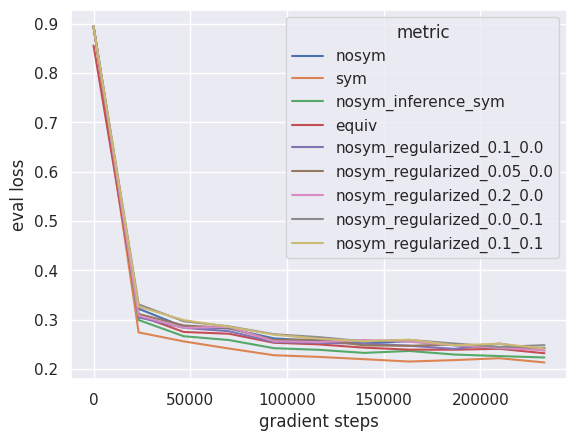

In [6]:
df = pd.DataFrame(rows)
sns.set_theme()
plot_df = df[df.metric.str.contains("train")]

sns.lineplot(data=plot_df, x="step", y="value", hue="metric")

sns.set_theme()
plot_df = df[df.metric.str.contains("eval")]
plot_df.loc[:, "metric"] = plot_df["metric"].apply(lambda x: x.replace("eval_", ""))
sns.lineplot(data=plot_df, x="step", y="value", hue="metric")
plt.ylabel("eval loss")
plt.xlabel("gradient steps")

Text(0.5, 0, 'gradient steps')

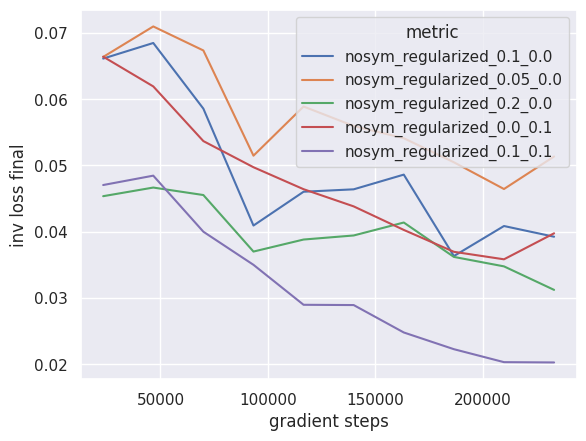

In [7]:
df = pd.DataFrame(rows)
sns.set_theme()
plot_df = df[df.metric.str.contains("train")]

sns.lineplot(data=plot_df, x="step", y="value", hue="metric")

sns.set_theme()
plot_df = df[df.metric.str.contains("inv_loss_final_")]
plot_df.loc[:, "metric"] = plot_df["metric"].apply(lambda x: x.replace("inv_loss_final_", ""))
sns.lineplot(data=plot_df, x="step", y="value", hue="metric")
plt.ylabel("inv loss final")
plt.xlabel("gradient steps")

Text(0.5, 0, 'gradient steps')

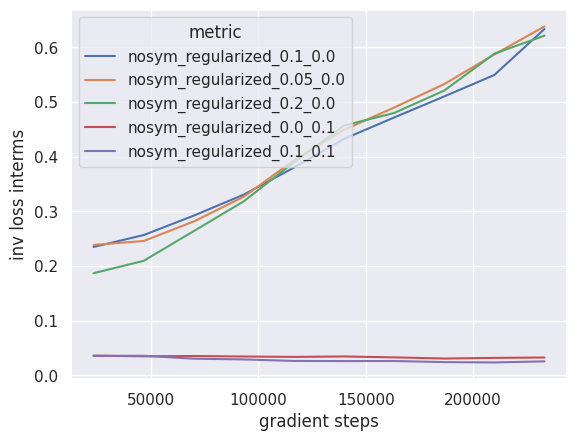

In [8]:
df = pd.DataFrame(rows)
sns.set_theme()
plot_df = df[df.metric.str.contains("train")]

sns.lineplot(data=plot_df, x="step", y="value", hue="metric")

sns.set_theme()
plot_df = df[df.metric.str.contains("inv_loss_interms_")]
plot_df.loc[:, "metric"] = plot_df["metric"].apply(lambda x: x.replace("inv_loss_interms_", ""))
sns.lineplot(data=plot_df, x="step", y="value", hue="metric")
plt.ylabel("inv loss interms")
plt.xlabel("gradient steps")